# Cell Biology, Jalali-Lab Style: Yeast -> Plant Cell

Three biology topics, each one a physics/CS topic this repo already has in a
different costume, built in `dgs/cell_biology.py`:

- **Membrane transport** (diffusion, osmosis) -- Fick's law, the same
  diffusion equation as the imaginary-time random walk in
  `dgs.path_integral_qkd` (distance grows as $\sqrt{t}$, not $t$, in both).
- **Heredity** (Mendelian crosses) -- a discrete probability distribution,
  the same machinery `dgs.bayes_inference` uses for posteriors.
- **Photosynthesis** (light absorption) -- Beer-Lambert attenuation,
  literally an absorption-spectrometer measurement, just done by a
  chloroplast instead of a photodiode.

**The level-up:** a yeast cell has osmosis only; a plant cell adds a rigid
cell wall (turgor pressure, which is *why* plants don't lyse in fresh water
the way an unwalled cell would) and a chloroplast that absorbs light. Same
diffusion core, two new physics layers.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import cell_biology as cb

plt.rcParams["figure.dpi"] = 110


## 1. Membrane transport: diffusion is slow because $x \sim \sqrt{Dt}$, not $Dt$


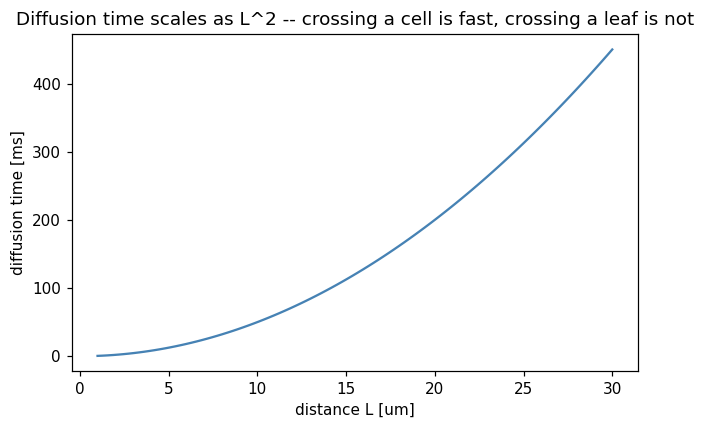

In [2]:
L_values = np.linspace(1e-6, 30e-6, 100)   # 1-30 micrometers, cell-scale
D = 1e-9                                    # m^2/s, a small-molecule diffusion coefficient in water
times = cb.diffusion_time_scale(L_values, D)

plt.figure(figsize=(6, 4))
plt.plot(L_values * 1e6, times * 1000, color="steelblue")
plt.xlabel("distance L [um]")
plt.ylabel("diffusion time [ms]")
plt.title("Diffusion time scales as L^2 -- crossing a cell is fast, crossing a leaf is not")
plt.tight_layout()
plt.show()


## 2. Heredity: a monohybrid Punnett cross is a probability table


genotype counts (Aa x Aa): {'AA': 1, 'Aa': 2, 'aa': 1}
phenotype ratio: {'dominant': 3, 'recessive': 1}


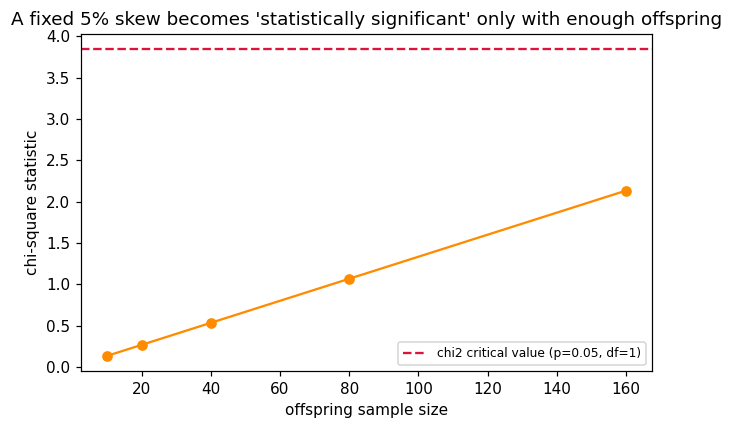

In [3]:
cross = cb.punnett_cross("Aa", "Aa")
pheno = cb.phenotype_ratio(cross, "A")
print("genotype counts (Aa x Aa):", cross)
print("phenotype ratio:", pheno)

# how much data would it take to *detect* a deviation from the 3:1 ratio?
import itertools
sample_sizes = [10, 20, 40, 80, 160]
chi2_vals = []
for n in sample_sizes:
    expected = [3 * n / 4, n / 4]
    observed_skewed = [3 * n / 4 - 0.05 * n, n / 4 + 0.05 * n]  # a 5%-of-n skew
    chi2_vals.append(cb.chi_square_heredity_test(observed_skewed, expected))

plt.figure(figsize=(6, 4))
plt.plot(sample_sizes, chi2_vals, "o-", color="darkorange")
plt.axhline(3.841, ls="--", color="crimson", label="chi2 critical value (p=0.05, df=1)")
plt.xlabel("offspring sample size")
plt.ylabel("chi-square statistic")
plt.title("A fixed 5% skew becomes 'statistically significant' only with enough offspring")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Photosynthesis: the chlorophyll action spectrum is an absorption spectrum


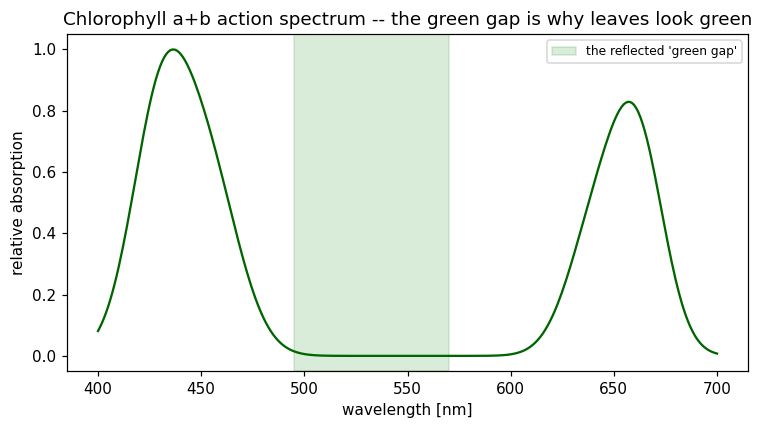

quantum yield example (85 electrons / 100 photons): 0.85


In [4]:
wavelengths = np.linspace(400, 700, 300)
spectrum = cb.chlorophyll_action_spectrum(wavelengths)

plt.figure(figsize=(7, 4))
plt.plot(wavelengths, spectrum, color="darkgreen")
plt.axvspan(495, 570, color="green", alpha=0.15, label="the reflected 'green gap'")
plt.xlabel("wavelength [nm]")
plt.ylabel("relative absorption")
plt.title("Chlorophyll a+b action spectrum -- the green gap is why leaves look green")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("quantum yield example (85 electrons / 100 photons):", cb.quantum_yield(85, 100))


## 4. The level-up: yeast cell vs. plant cell water balance

Same osmotic pressures, same diffusion core. The plant cell's wall adds a
turgor back-pressure that caps net water influx -- an unwalled cell under
the same osmotic gradient would keep taking on water unchecked.


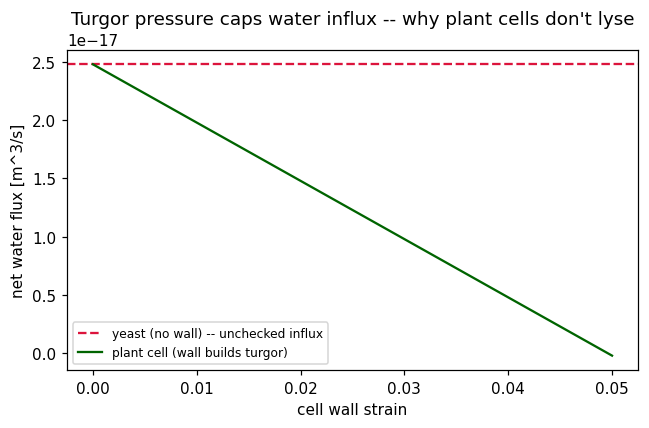

plant cell at moderate turgor, lit at 662nm (red, chlorophyll-a peak):
  Pi_in                    = 743313
  Pi_out                   = 247771
  P_wall                   = 300000
  water_flux               = 9.7771e-18
  absorbed_light_fraction  = 1
  absorbed_light           = 1


In [5]:
C_in, C_out = 300, 100   # mol/m^3, hypertonic cytoplasm relative to a fresh-water bath
strains = np.linspace(0, 0.05, 40)

yeast = cb.yeast_cell_water_balance(C_in, C_out)
plant_fluxes = [cb.plant_cell_water_balance(C_in, C_out, wall_strain=s)["water_flux"] for s in strains]

plt.figure(figsize=(6, 4))
plt.axhline(yeast["water_flux"], ls="--", color="crimson", label="yeast (no wall) -- unchecked influx")
plt.plot(strains, plant_fluxes, color="darkgreen", label="plant cell (wall builds turgor)")
plt.xlabel("cell wall strain")
plt.ylabel("net water flux [m^3/s]")
plt.title("Turgor pressure caps water influx -- why plant cells don't lyse")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plant_with_light = cb.plant_cell_water_balance(C_in, C_out, wall_strain=0.03, light_intensity=1.0, wavelength_nm=662.0)
print("plant cell at moderate turgor, lit at 662nm (red, chlorophyll-a peak):")
for k, v in plant_with_light.items():
    print(f"  {k:24s} = {v:.6g}")


## Summary

Three biology topics, each reusing physics already verified elsewhere in this
repo: diffusion's $\sqrt{t}$ scaling matches the imaginary-time random walk in
`path_integral_qkd`, Mendelian ratios are a probability table like
`bayes_inference`'s posteriors, and the chlorophyll action spectrum is a Beer-
Lambert absorption measurement -- an optics measurement, just done by a leaf.
The yeast-to-plant level-up is literal: identical diffusion core, plus a wall
(turgor) and a chloroplast (light absorption) layered on top.
